<a href="https://colab.research.google.com/github/joffretacor-web/prueba2/blob/main/CNN_vs_RedNeuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación: Red Neuronal Tradicional vs Red Neuronal Convolucional (CNN)
Este notebook compara el desempeño de una red neuronal tradicional con una CNN usando el dataset MNIST.

## 0. Instalación de Dependencias

In [ ]:
# Instalar librerías necesarias
!pip install -q tensorflow matplotlib opencv-python pillow

## 1. Importar librerías

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io
from google.colab import files

#print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Cargar y preparar datos MNIST

In [ ]:
# Cargar dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Forma de datos de entrenamiento: {X_train.shape}')
print(f'Forma de datos de prueba: {X_test.shape}')

# Normalizar datos (escalar a rango 0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f'Rango de valores después de normalización: [{X_train.min()}, {X_train.max()}]')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de datos de entrenamiento: (60000, 28, 28)
Forma de datos de prueba: (10000, 28, 28)
Rango de valores después de normalización: [0.0, 1.0]


## PARTE 1: RED NEURONAL TRADICIONAL (DENSA)

### 1.1 Preparación de datos para red neuronal densa

In [ ]:
# Para red densa, aplanar las imágenes (28x28 -> 784)
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print(f'Forma de datos aplanados: {X_train_flat.shape}')

Forma de datos aplanados: (60000, 784)


### 1.2 Construcción de Red Neuronal Tradicional

In [ ]:
# Crear modelo de red neuronal tradicional (denso)
model_tradicional = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), name='capa_entrada'),
    layers.Dropout(0.2, name='dropout_1'),
    layers.Dense(64, activation='relu', name='capa_oculta_1'),
    layers.Dropout(0.2, name='dropout_2'),
    layers.Dense(32, activation='relu', name='capa_oculta_2'),
    layers.Dense(10, activation='softmax', name='capa_salida')
])

print('Arquitectura de Red Neuronal Tradicional:')
model_tradicional.summary()

Arquitectura de Red Neuronal Tradicional:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_entrada (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_1 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

### 1.3 Compilación de Red Neuronal Tradicional

In [ ]:
# Compilar el modelo
model_tradicional.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 1.4 Entrenamiento de Red Neuronal Tradicional

In [ ]:
# Entrenar el modelo
print('Entrenando Red Neuronal Tradicional...')
history_tradicional = model_tradicional.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Entrenando Red Neuronal Tradicional...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8841 - loss: 0.3829 - val_accuracy: 0.9667 - val_loss: 0.1186
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9460 - loss: 0.1796 - val_accuracy: 0.9733 - val_loss: 0.0912
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9575 - loss: 0.1422 - val_accuracy: 0.9750 - val_loss: 0.0883
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9641 - loss: 0.1209 - val_accuracy: 0.9760 - val_loss: 0.0785
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9673 - loss: 0.1069 - val_accuracy: 0.9752 - val_loss: 0.0854
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9711 - loss: 0.0960 - val_accuracy: 0.9788 - val_loss: 0.0708
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9728 - loss: 0.0868 - val_accuracy: 0.9775 - val_loss: 0.0786
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/s

### 1.5 Evaluación de Red Neuronal Tradicional


=== RESULTADOS RED NEURONAL TRADICIONAL ===
Loss (Pérdida): 0.0754
Accuracy (Precisión): 0.9769 (97.69%)


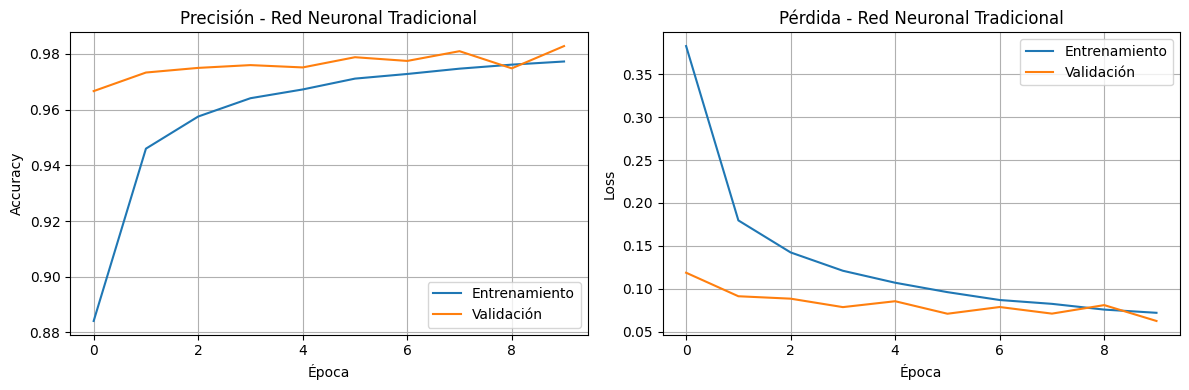

In [ ]:
# Evaluar en datos de prueba
loss_trad, accuracy_trad = model_tradicional.evaluate(X_test_flat, y_test, verbose=0)

print(f'\n=== RESULTADOS RED NEURONAL TRADICIONAL ===')
print(f'Loss (Pérdida): {loss_trad:.4f}')
print(f'Accuracy (Precisión): {accuracy_trad:.4f} ({accuracy_trad*100:.2f}%)')

# Visualizar historial de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_tradicional.history['accuracy'], label='Entrenamiento')
axes[0].plot(history_tradicional.history['val_accuracy'], label='Validación')
axes[0].set_title('Precisión - Red Neuronal Tradicional')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_tradicional.history['loss'], label='Entrenamiento')
axes[1].plot(history_tradicional.history['val_loss'], label='Validación')
axes[1].set_title('Pérdida - Red Neuronal Tradicional')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PARTE 2: RED NEURONAL CONVOLUCIONAL (CNN)

### 2.1 Preparación de datos para CNN

In [ ]:
# Para CNN, necesitamos datos con dimensión de canal (28x28x1)
# Las imágenes de MNIST son en escala de grises (1 canal)

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(f'Forma de datos para CNN: {X_train_cnn.shape}')
print(f'Dimensiones: (muestras, alto, ancho, canales)')

Forma de datos para CNN: (60000, 28, 28, 1)
Dimensiones: (muestras, alto, ancho, canales)


### 2.2 Construcción de CNN - Arquitectura Modular

In [ ]:
# Construir modelo CNN
model_cnn = models.Sequential()

# ============================================================
# SECCIÓN 1: CAPAS CONVOLUCIONALES (Detección de características)
# ============================================================
print('\n--- SECCIÓN 1: CAPAS CONVOLUCIONALES ---')

# Primera capa convolucional
model_cnn.add(layers.Conv2D(
    filters=32,           # Número de filtros
    kernel_size=(3, 3),   # Tamaño del filtro (3x3)
    activation='relu',
    input_shape=(28, 28, 1),
    name='conv2d_1'
))
print('✓ Conv2D_1: 32 filtros (3x3) - Detecta características básicas (bordes, líneas)')

# Segunda capa convolucional
model_cnn.add(layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu',
    name='conv2d_2'
))
print('✓ Conv2D_2: 64 filtros (3x3) - Combina características en patrones más complejos')

# ============================================================
# SECCIÓN 2: CAPAS DE POOLING (Reducción de dimensionalidad)
# ============================================================
print('\n--- SECCIÓN 2: CAPAS DE POOLING ---')

# Primera capa de pooling
model_cnn.add(layers.MaxPooling2D(
    pool_size=(2, 2),
    name='maxpool_1'
))
print('✓ MaxPooling_1: (2x2) - Reduce dimensión manteniendo características importantes')

# Segunda capa de pooling
model_cnn.add(layers.MaxPooling2D(
    pool_size=(2, 2),
    name='maxpool_2'
))
print('✓ MaxPooling_2: (2x2) - Segunda reducción de dimensión')

# ============================================================
# SECCIÓN 3: NORMALIZACIÓN Y REGULARIZACIÓN
# ============================================================
print('\n--- SECCIÓN 3: NORMALIZACIÓN Y REGULARIZACIÓN ---')

# Aplanar los datos para las capas densas
model_cnn.add(layers.Flatten(name='flatten'))
print('✓ Flatten: Convierte mapas de características a vector')

# Dropout para regularización
model_cnn.add(layers.Dropout(0.5, name='dropout_1'))
print('✓ Dropout: 50% - Previene sobreajuste')

# ============================================================
# SECCIÓN 4: CAPAS DENSAS (Clasificación)
# ============================================================
print('\n--- SECCIÓN 4: CAPAS COMPLETAMENTE CONECTADAS ---')

# Capa densa oculta
model_cnn.add(layers.Dense(
    units=128,
    activation='relu',
    name='dense_1'
))
print('✓ Dense_1: 128 neuronas - Aprende combinaciones de características')

# Dropout adicional
model_cnn.add(layers.Dropout(0.3, name='dropout_2'))
print('✓ Dropout: 30% - Regularización adicional')

# Capa de salida
model_cnn.add(layers.Dense(
    units=10,
    activation='softmax',
    name='output'
))
print('✓ Output: 10 neuronas (softmax) - Clasificación final (dígitos 0-9)')

print('\n' + '='*60)
print('ARQUITECTURA COMPLETA DE CNN')
print('='*60)
model_cnn.summary()


--- SECCIÓN 1: CAPAS CONVOLUCIONALES ---
✓ Conv2D_1: 32 filtros (3x3) - Detecta características básicas (bordes, líneas)
✓ Conv2D_2: 64 filtros (3x3) - Combina características en patrones más complejos

--- SECCIÓN 2: CAPAS DE POOLING ---
✓ MaxPooling_1: (2x2) - Reduce dimensión manteniendo características importantes
✓ MaxPooling_2: (2x2) - Segunda reducción de dimensión

--- SECCIÓN 3: NORMALIZACIÓN Y REGULARIZACIÓN ---
✓ Flatten: Convierte mapas de características a vector
✓ Dropout: 50% - Previene sobreajuste

--- SECCIÓN 4: CAPAS COMPLETAMENTE CONECTADAS ---
✓ Dense_1: 128 neuronas - Aprende combinaciones de características
✓ Dropout: 30% - Regularización adicional
✓ Output: 10 neuronas (softmax) - Clasificación final (dígitos 0-9)

ARQUITECTURA COMPLETA DE CNN


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,146 (1.20 MB)

 Trainable params: 315,146 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Compilación de CNN

In [ ]:
# Compilar el modelo CNN
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('✓ Modelo compilado exitosamente')
print('  Optimizador: Adam')
print('  Función de pérdida: Categorical crossentropy')
print('  Métrica: Accuracy')

✓ Modelo compilado exitosamente
  Optimizador: Adam
  Función de pérdida: Categorical crossentropy
  Métrica: Accuracy


### 2.4 Entrenamiento de CNN

In [ ]:
# Entrenar el modelo CNN
print('Entrenando Red Neuronal Convolucional (CNN)...')
print('Esto puede tardar algunos minutos...\n')

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Entrenando Red Neuronal Convolucional (CNN)...
Esto puede tardar algunos minutos...

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 137s 81ms/step - accuracy: 0.9369 - loss: 0.2045 - val_accuracy: 0.9862 - val_loss: 0.0488
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 134s 79ms/step - accuracy: 0.9748 - loss: 0.0808 - val_accuracy: 0.9902 - val_loss: 0.0372
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 134s 79ms/step - accuracy: 0.9787 - loss: 0.0659 - val_accuracy: 0.9918 - val_loss: 0.0324
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 143s 80ms/step - accuracy: 0.9819 - loss: 0.0568 - val_accuracy: 0.9922 - val_loss: 0.0285
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 135s 80ms/step - accuracy: 0.9846 - loss: 0.0514 - val_accuracy: 0.9918 - val_loss: 0.0293
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 136s 80ms/step - accuracy: 0.9851 - loss: 0.0469 - val_accuracy: 0.9922 - val_loss: 0.0268
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 136s 81ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9913 - v

### 2.5 Evaluación de CNN


=== RESULTADOS CNN ===
Loss (Pérdida): 0.0245
Accuracy (Precisión): 0.9922 (99.22%)


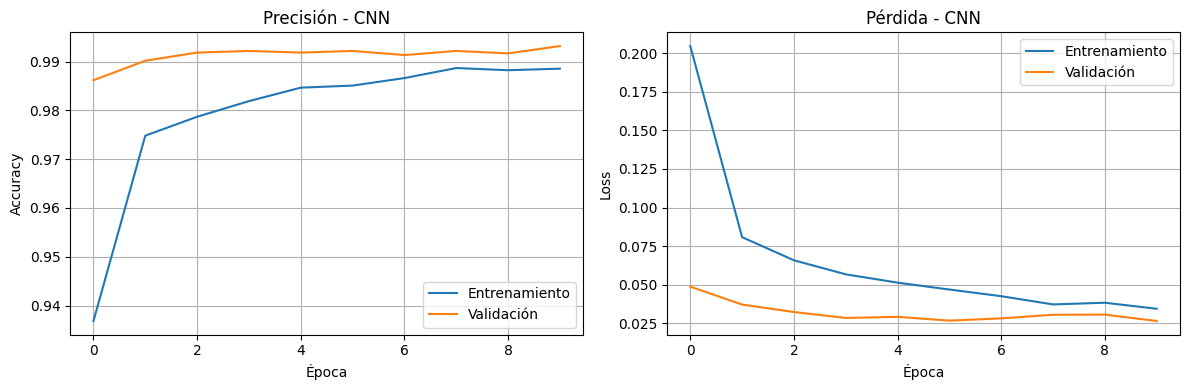

In [ ]:
# Evaluar CNN en datos de prueba
loss_cnn, accuracy_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)

print(f'\n=== RESULTADOS CNN ===')
print(f'Loss (Pérdida): {loss_cnn:.4f}')
print(f'Accuracy (Precisión): {accuracy_cnn:.4f} ({accuracy_cnn*100:.2f}%)')

# Visualizar historial de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history['accuracy'], label='Entrenamiento')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validación')
axes[0].set_title('Precisión - CNN')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_cnn.history['loss'], label='Entrenamiento')
axes[1].plot(history_cnn.history['val_loss'], label='Validación')
axes[1].set_title('Pérdida - CNN')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PARTE 3: COMPARACIÓN DE RESULTADOS


COMPARACIÓN: RED NEURONAL TRADICIONAL vs CNN

📊 Red Neuronal Tradicional:
   - Precisión: 97.69%
   - Pérdida: 0.0754
   - Parámetros totales: 111,146

🧠 Red Neuronal Convolucional (CNN):
   - Precisión: 99.22%
   - Pérdida: 0.0245
   - Parámetros totales: 315,146

🎯 Ventaja de CNN: 1.53% más precisa


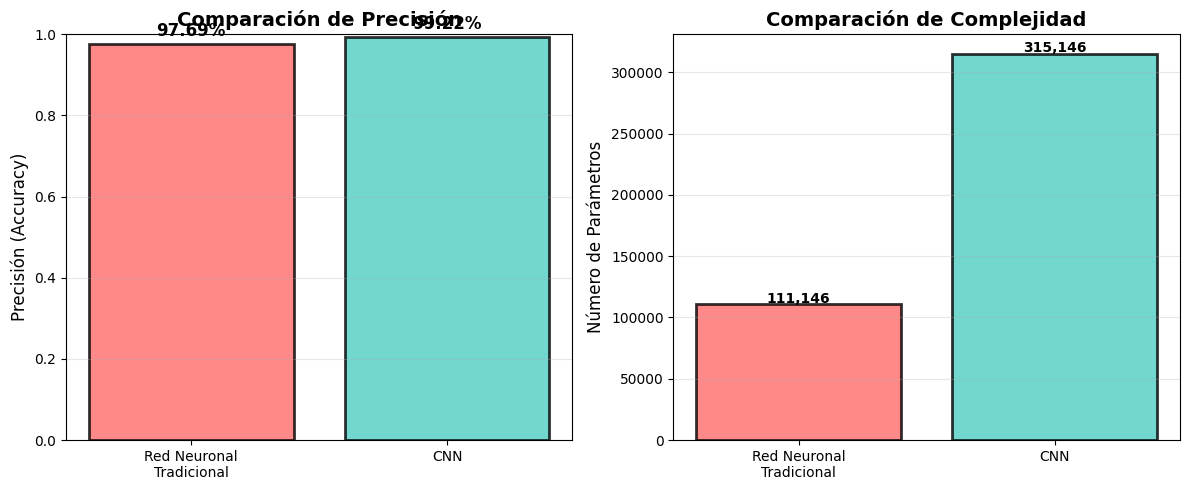

In [ ]:
# Comparación de resultados
print('\n' + '='*60)
print('COMPARACIÓN: RED NEURONAL TRADICIONAL vs CNN')
print('='*60)

print(f'\n📊 Red Neuronal Tradicional:')
print(f'   - Precisión: {accuracy_trad*100:.2f}%')
print(f'   - Pérdida: {loss_trad:.4f}')
print(f'   - Parámetros totales: {model_tradicional.count_params():,}')

print(f'\n🧠 Red Neuronal Convolucional (CNN):')
print(f'   - Precisión: {accuracy_cnn*100:.2f}%')
print(f'   - Pérdida: {loss_cnn:.4f}')
print(f'   - Parámetros totales: {model_cnn.count_params():,}')

print(f'\n🎯 Ventaja de CNN: {(accuracy_cnn - accuracy_trad)*100:.2f}% más precisa')

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos = ['Red Neuronal\nTradicional', 'CNN']
accuracies = [accuracy_trad, accuracy_cnn]
colors = ['#FF6B6B', '#4ECDC4']

axes[0].bar(modelos, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Precisión (Accuracy)', fontsize=12)
axes[0].set_title('Comparación de Precisión', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

params = [model_tradicional.count_params(), model_cnn.count_params()]
axes[1].bar(modelos, params, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Número de Parámetros', fontsize=12)
axes[1].set_title('Comparación de Complejidad', fontsize=14, fontweight='bold')
for i, v in enumerate(params):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## PARTE 4: PRUEBA CON IMAGEN PERSONALIZADA

### 4.1 Cargar imagen personalizada

In [ ]:
# Cargar imagen desde archivo
print('Por favor, suba una imagen de un dígito manuscrito (28x28 recomendado):')
print('Formatos soportados: JPG, PNG, BMP, GIF\n')

uploaded = files.upload()

if len(uploaded) > 0:
    # Obtener el nombre del archivo
    filename = list(uploaded.keys())[0]
    print(f'\n✓ Archivo cargado: {filename}')
else:
    print('No se cargó ningún archivo. Se usará una imagen de prueba del dataset.')
    # Usar imagen del dataset como ejemplo
    filename = None

Por favor, suba una imagen de un dígito manuscrito (28x28 recomendado):
Formatos soportados: JPG, PNG, BMP, GIF



Saving imagen prueba.jpg to imagen prueba (1).jpg

✓ Archivo cargado: imagen prueba (1).jpg


### 4.2 Procesar y visualizar imagen

Dimensiones de la imagen: (28, 28)


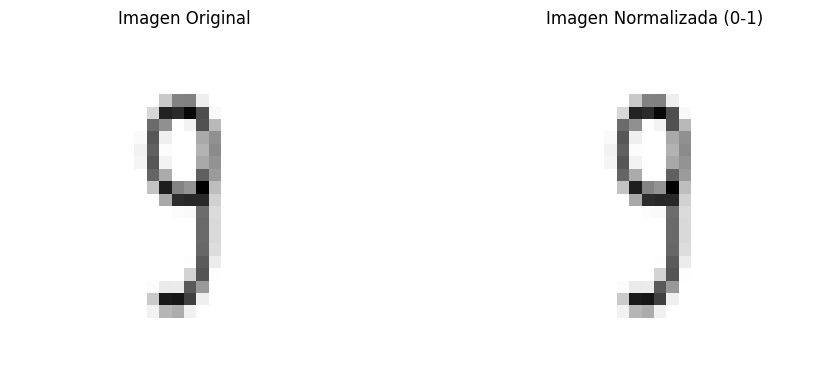

In [ ]:
if filename:
    # Cargar imagen
    img = Image.open(filename).convert('L')  # Convertir a escala de grises

    # Redimensionar a 28x28 (tamaño de MNIST)
    img = img.resize((28, 28))

    # Convertir a array numpy
    img_array = np.array(img, dtype='float32')

    print(f'Dimensiones de la imagen: {img_array.shape}')
else:
    # Usar imagen del dataset
    print('Usando imagen de prueba del dataset MNIST...')
    img_array = X_test[0] * 255  # Convertir de vuelta a rango 0-255
    img_array = img_array.astype('float32')

# Normalizar imagen
img_normalized = img_array / 255.0

# Visualizar imagen original
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(img_normalized, cmap='gray')
axes[1].set_title('Imagen Normalizada (0-1)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 4.3 Predicción con Red Neuronal Tradicional

In [ ]:
# Preparar imagen para red neuronal tradicional (aplanar)
img_flat = img_normalized.reshape(1, -1)

# Hacer predicción
prediction_trad = model_tradicional.predict(img_flat, verbose=0)
predicted_class_trad = np.argmax(prediction_trad[0])
confidence_trad = prediction_trad[0][predicted_class_trad]

print('\n=== PREDICCIÓN CON RED NEURONAL TRADICIONAL ===')
print(f'Dígito predicho: {predicted_class_trad}')
print(f'Confianza: {confidence_trad*100:.2f}%')
print(f'\nProbabilidades para cada dígito:')

for i, prob in enumerate(prediction_trad[0]):
    bar = '█' * int(prob * 40)
    print(f'  {i}: {bar} {prob*100:.2f}%')

InvalidArgumentError: Graph execution error:

Detected at node sequential_1/capa_entrada_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 203, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.13/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.13/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.13/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.13/asyncio/base_events.py", line 684, in run_forever

  File "/usr/lib/python3.13/asyncio/base_events.py", line 2061, in _run_once

  File "/usr/lib/python3.13/asyncio/events.py", line 89, in _run

  File "/usr/local/lib/python3.13/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.13/d

### 4.4 Predicción con CNN

In [ ]:
# Preparar imagen para CNN (mantener dimensiones)
img_cnn = img_normalized.reshape(1, 28, 28, 1)

# Hacer predicción
prediction_cnn = model_cnn.predict(img_cnn, verbose=0)
predicted_class_cnn = np.argmax(prediction_cnn[0])
confidence_cnn = prediction_cnn[0][predicted_class_cnn]

print('\n=== PREDICCIÓN CON CNN ===')
print(f'Dígito predicho: {predicted_class_cnn}')
print(f'Confianza: {confidence_cnn*100:.2f}%')
print(f'\nProbabilidades para cada dígito:')

for i, prob in enumerate(prediction_cnn[0]):
    bar = '█' * int(prob * 40)
    print(f'  {i}: {bar} {prob*100:.2f}%')


=== PREDICCIÓN CON CNN ===
Dígito predicho: 8
Confianza: 92.57%

Probabilidades para cada dígito:
  0:  0.63%
  1:  0.05%
  2: █ 3.04%
  3:  2.12%
  4:  0.01%
  5:  0.70%
  6:  0.36%
  7:  0.03%
  8: █████████████████████████████████████ 92.57%
  9:  0.49%


### 4.5 Visualización Comparativa de Predicciones

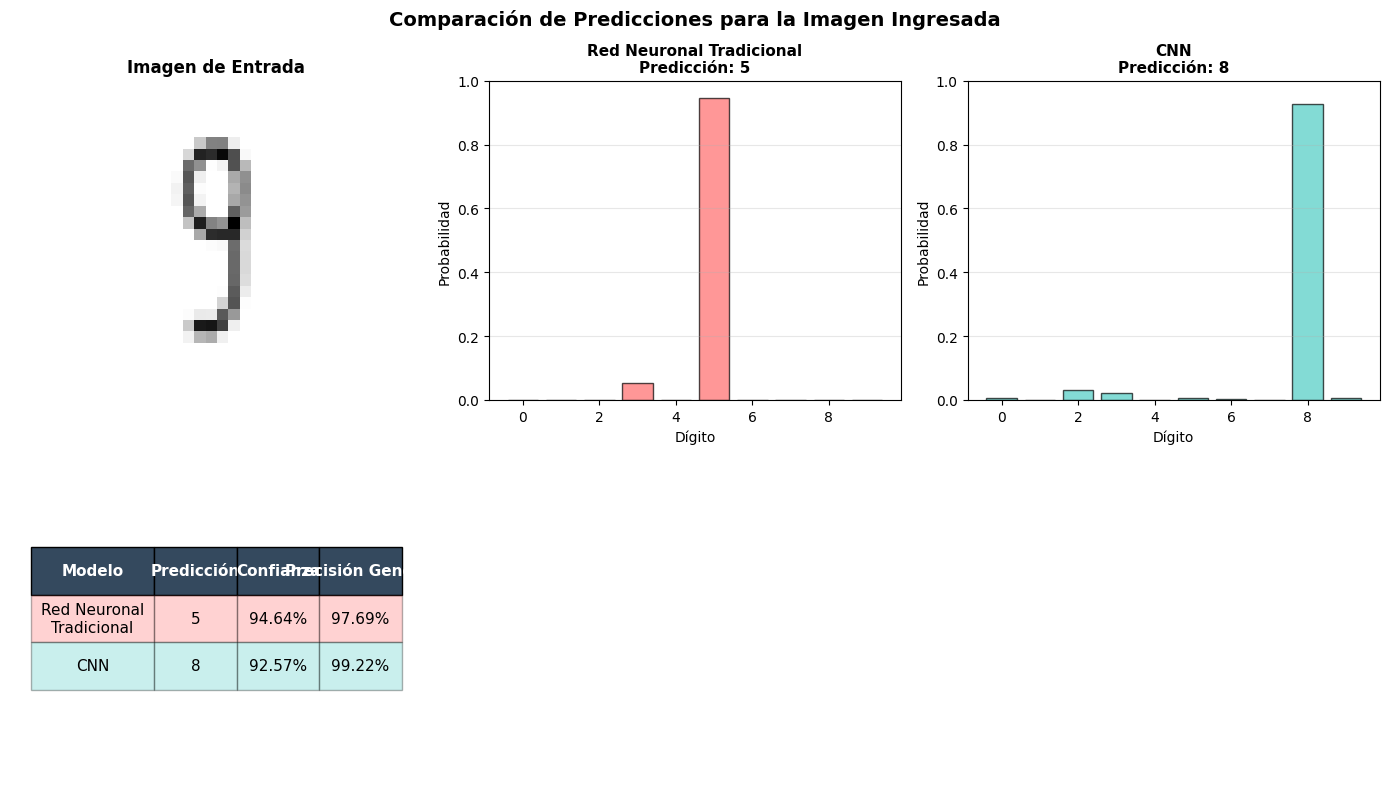


✓ Análisis completado


In [ ]:
# Comparar predicciones
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Imagen original
axes[0, 0].imshow(img_normalized, cmap='gray')
axes[0, 0].set_title('Imagen de Entrada', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Predicción Red Neuronal Tradicional
axes[0, 1].bar(range(10), prediction_trad[0], color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 1].set_title(f'Red Neuronal Tradicional\nPredicción: {predicted_class_trad}', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Dígito')
axes[0, 1].set_ylabel('Probabilidad')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Predicción CNN
axes[0, 2].bar(range(10), prediction_cnn[0], color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[0, 2].set_title(f'CNN\nPredicción: {predicted_class_cnn}', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Dígito')
axes[0, 2].set_ylabel('Probabilidad')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Tabla comparativa
# Iterar sobre los subplots de la segunda fila para apagar sus ejes
for ax in axes[1, :]:
    ax.axis('off')

table_data = [
    ['Modelo', 'Predicción', 'Confianza', 'Precisión General'],
    ['Red Neuronal\nTradicional', f'{predicted_class_trad}', f'{confidence_trad*100:.2f}%', f'{accuracy_trad*100:.2f}%'],
    ['CNN', f'{predicted_class_cnn}', f'{confidence_cnn*100:.2f}%', f'{accuracy_cnn*100:.2f}%']
]

# Crear la tabla en el primer subplot de la segunda fila, que ya tiene los ejes apagados
table = axes[1, 0].table(cellText=table_data, cellLoc='center', loc='center',
                          colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Colorear encabezado
for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorear filas
for i in range(4):
    table[(1, i)].set_facecolor('#FF6B6B')
    table[(1, i)].set_alpha(0.3)
    table[(2, i)].set_facecolor('#4ECDC4')
    table[(2, i)].set_alpha(0.3)

plt.suptitle('Comparación de Predicciones para la Imagen Ingresada', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print('\n✓ Análisis completado')


## CONCLUSIONES

In [ ]:
print('\n' + '='*70)
print('CONCLUSIONES Y ANÁLISIS')
print('='*70)

print(f'''
🔍 RESULTADOS GENERALES:

Red Neuronal Tradicional:
  • Precisión: {accuracy_trad*100:.2f}%
  • Parámetros: {model_tradicional.count_params():,}
  • Ventaja: Más simple, fácil de entender
  • Desventaja: Menos eficiente para imágenes

Red Neuronal Convolucional (CNN):
  • Precisión: {accuracy_cnn*100:.2f}%
  • Parámetros: {model_cnn.count_params():,}
  • Ventaja: Mejor precisión, captura relaciones espaciales
  • Desventaja: Más compleja, requiere más recursos

📊 ANÁLISIS:

1. ARQUITECTURA:
   - La red tradicional aplana toda la imagen (28x28=784 entrada)
   - La CNN preserva la estructura espacial (28x28x1 entrada)

2. VENTAJAS DE CNN:
   - Las convoluciones detectan características locales (bordes, formas)
   - El pooling reduce dimensionalidad sin perder información importante
   - Compartir pesos reduce parámetros comparado con redes densas

3. CARACTERÍSTICAS APRENDIDAS:
   - Capa 1: Detecta bordes y líneas simples
   - Capa 2: Detecta formas más complejas
   - Pooling: Mantiene las características más importantes
   - Capas densas: Clasifican el dígito final

4. RECOMENDACIONES:
   - Para problemas de visión por computadora: Usar CNN
   - Para datos tabulares: Usar redes densas tradicionales
   - Para problemas complejos: Considerar arquitecturas más avanzadas
''')

print('='*70)


CONCLUSIONES Y ANÁLISIS

🔍 RESULTADOS GENERALES:

Red Neuronal Tradicional:
  • Precisión: 97.69%
  • Parámetros: 111,146
  • Ventaja: Más simple, fácil de entender
  • Desventaja: Menos eficiente para imágenes

Red Neuronal Convolucional (CNN):
  • Precisión: 99.22%
  • Parámetros: 315,146
  • Ventaja: Mejor precisión, captura relaciones espaciales
  • Desventaja: Más compleja, requiere más recursos

📊 ANÁLISIS:

1. ARQUITECTURA:
   - La red tradicional aplana toda la imagen (28x28=784 entrada)
   - La CNN preserva la estructura espacial (28x28x1 entrada)

2. VENTAJAS DE CNN:
   - Las convoluciones detectan características locales (bordes, formas)
   - El pooling reduce dimensionalidad sin perder información importante
   - Compartir pesos reduce parámetros comparado con redes densas

3. CARACTERÍSTICAS APRENDIDAS:
   - Capa 1: Detecta bordes y líneas simples
   - Capa 2: Detecta formas más complejas
   - Pooling: Mantiene las características más importantes
   - Capas densas: Clasif